In [1]:
from unstructured.partition.pdf import partition_pdf

elements=partition_pdf("attention.pdf",strategy='hi_res',infer_table_structure=True)

No languages specified, defaulting to English.


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [2]:
elements

In [3]:
from unstructured.documents.elements import NarrativeText,Title,ListItem,Table

filtered_docs=[]

filtered_tables=[]

allowed_types=(NarrativeText,Title,ListItem)

for e in elements:
    if isinstance(e,allowed_types):
        text=str(e).strip()
        if len(text)>40:
            filtered_docs.append(text)
    elif isinstance(e,Table):
        filtered_tables.append(e)

In [4]:
filtered_tables

In [5]:
tab=filtered_tables[0].to_dict()
tab

{'type': 'Table',
 'element_id': '58246ac1d674122055fa1f9b8e56318d',
 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)',
 'metadata': {'detection_class_prob': 0.9282334446907043,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(561.3709716796875),
     np.float64(550.45751953125)),
    (np.float64(561.3709716796875), np.float64(908.8243408203125)),
    (np.float64(2395.14013671875), np.float64(908.8243408203125)),
    (np.float64(2395.14013671875), np.float64(550.45751953125))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-05-06T11:02:04',
  'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Atten

In [6]:
tab.keys()

dict_keys(['type', 'element_id', 'text', 'metadata'])

In [7]:
tab["metadata"]['text_as_html']

'<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td><td>O(n? - d)</td><td>O(1)</td><td>O(1)</td></tr><tr><td>Recurrent</td><td>O(n - d?)</td><td>O(n)</td><td>O(n)</td></tr><tr><td>Convolutional</td><td>O(k-n-d?)</td><td>O(1)</td><td>O(log, (n))</td></tr><tr><td>Self-Attention (restricted)</td><td>O(r-n-d)</td><td>O(1)</td><td>O(n/r)</td></tr></tbody></table>'

In [8]:
from io import StringIO

In [9]:
tab1=StringIO(tab["metadata"]['text_as_html'])
tab1

In [10]:
import pandas as pd

tab1=pd.read_html(tab1)[0]
tab1

,Layer Type,Complexity per Layer,Sequential Operations,Maximum Path Length
0,Self-Attention,O(n? - d),O(1),O(1)
1,Recurrent,O(n - d?),O(n),O(n)
2,Convolutional,O(k-n-d?),O(1),"O(log, (n))"
3,Self-Attention (restricted),O(r-n-d),O(1),O(n/r)


In [11]:
tab1.to_markdown()

'|    | Layer Type                  | Complexity per Layer   | Sequential Operations   | Maximum Path Length   |\n|---:|:----------------------------|:-----------------------|:------------------------|:----------------------|\n|  0 | Self-Attention              | O(n? - d)              | O(1)                    | O(1)                  |\n|  1 | Recurrent                   | O(n - d?)              | O(n)                    | O(n)                  |\n|  2 | Convolutional               | O(k-n-d?)              | O(1)                    | O(log, (n))           |\n|  3 | Self-Attention (restricted) | O(r-n-d)               | O(1)                    | O(n/r)                |'

In [12]:
from langchain_core.documents import Document

docs=[Document(page_content=d,metadata={"name":"attention.pdf"}) for d in filtered_docs]

docs


[Document(metadata={'name': 'attention.pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.'),
 Document(metadata={'name': 'attention.pdf'}, page_content='Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu'),
 Document(metadata={'name': 'attention.pdf'}, page_content='Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com'),
 Document(metadata={'name': 'attention.pdf'}, page_content='The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200, separators=["\n\n","\n",". "," ",""])

chunks=splitter.split_documents(docs)

chunks

[Document(metadata={'name': 'attention.pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.'),
 Document(metadata={'name': 'attention.pdf'}, page_content='Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu'),
 Document(metadata={'name': 'attention.pdf'}, page_content='Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com'),
 Document(metadata={'name': 'attention.pdf'}, page_content='The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be

In [14]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")

vectorstore=FAISS.from_documents(chunks,embeddings)

retriever=vectorstore.as_retriever(search_kwargs={"k":3})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
retriever.invoke("Explain about attention mechanism")

[Document(id='dce05b78-29ca-4067-ac88-185c82ff8d7d', metadata={'name': 'attention.pdf'}, page_content='3.2.3 Applications of Attention in our Model'),
 Document(id='83828270-6574-43dd-b74c-ac53589e09f4', metadata={'name': 'attention.pdf'}, page_content='An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum'),
 Document(id='d238c956-c97d-46d3-a623-b2db9f0c0f3c', metadata={'name': 'attention.pdf'}, page_content='Attention mechanisms have become an integral part of compelling sequence modeling and transduc- tion models in various tasks, allowing modeling of dependencies without regard to their distance in the input or output sequences [2, 19]. In all but a few cases [27], however, such attention mechanisms are used in conjunction with a recurrent network.')]

In [16]:
rr=vectorstore.similarity_search_with_score("explain about pharse 4 of marvel cinematic universe")
rr

[(Document(id='af40d98c-e694-4b0c-b18b-cefb1aacaa1e', metadata={'name': 'attention.pdf'}, page_content='output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2.'),
  np.float32(1.6105857)),
 (Document(id='69404457-8048-46f0-b876-5cc51cdf3320', metadata={'name': 'attention.pdf'}, page_content='[30] Ofir Press and Lior Wolf. Using the output embedding to improve language models. arXiv preprint arXiv:1608.05859, 2016.'),
  np.float32(1.6209701)),
 (Document(id='dfaa7280-d2bb-4fab-80c9-71b9070ee528', metadata={'name': 'attention.pdf'}, page_content='Figure 4: Two attention heads, also in layer 5 of 6, apparently involved in anaphora resolution. Top: Full attentions for head 5. Bottom: Isolated attentions from just the word ‘its’ for attention heads 5 and 6. Note that the attentions are very sharp for this word.'),
  np.float32(1.6434377)),
 (Document(id='33d55bca-1a6a-4780-9285-728138a25093', metadata={'name': 'attention.pdf'},

In [17]:
for d, s in rr:
    print(s)

1.6105857
1.6209701
1.6434377
1.7078633


In [18]:
from typing import TypedDict,List
from typing_extensions import Annotated
from langgraph.graph import StateGraph,START,END
from langchain.chat_models import init_chat_model

In [19]:
from all_api import google_api

In [20]:
llm=init_chat_model("google_genai:gemini-2.5-flash",api_key=google_api)
llm

ChatGoogleGenerativeAI(profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x701e2e5eafc0>, default_metadata=(), model_kwargs={})

In [21]:
class State(TypedDict):
    question:str
    answer:str
    document:List[Document]
    evidence:str

In [22]:
def retrive_documents(state:State):
    """Retrieve relevant docuements based on the question"""
    question=state['question']
    documents=[]
    results=vectorstore.similarity_search_with_score(question)
    for doc, score in results:
        if score<=1.0:
            documents.append(doc)
    return {**state,"document":documents}

In [23]:
def evidence_evaluater(state:State):
    """Based on the retireved documents decide wheather the documents are sufficient to answer the question or not"""
    question=state["question"]
    documents=state.get("document",[])

    context="\n\n".join([doc.page_content for doc in documents])
    prompt=f"""Based on the Question, evaluated wheater the context has satisfactory data to answer the question to the fullest
    Question: {question}, Context: {context}. Return only 'FULL', 'PARTIAL', 'INSUFFICIENT' """

    response=llm.invoke(prompt)
    return {**state,"evidence":response.content.strip().upper()}

In [24]:
def generate_answer(state:State):
    """Generate answer using retrieved docuemtents or direct answer"""
    question=state["question"]

    documents=state.get("document",[])

    evidence_state=state["evidence"]

    context="\n\n".join([doc.page_content for doc in documents])

    if evidence_state=="FULL":
        prompt = f"""
        You are a document-grounded AI assistant.

        Answer the question ONLY using
        the provided context.

        CONTEXT:
        {context}

        QUESTION:
        {question}

        ANSWER:
        """
    elif evidence_state=="PARTIAL":
        prompt = f"""
        You are a document-grounded AI assistant.

        The retrieved context partially answers
        the user's question.

        Use the context as the PRIMARY source.

        You may supplement missing information
        using general knowledge, but clearly
        distinguish supplemental information
        from document-supported information.

        CONTEXT:
        {context}

        QUESTION:
        {question}

        ANSWER:
        """
    
    else:
        prompt = f"""
        The retrieved documents do not contain
        sufficient information to fully answer
        the question.

        Explain this limitation clearly.

        Then provide only a brief high-level
        answer if possible.

        QUESTION:
        {question}

        ANSWER:
        """
        
    response=llm.invoke(prompt)
    return {**state,"answer":response.content}

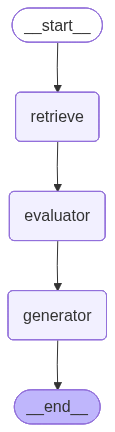

In [25]:
builder=StateGraph(State)

builder.add_node("retrieve",retrive_documents)
builder.add_node("evaluator",evidence_evaluater)
builder.add_node("generator",generate_answer)

builder.add_edge(START,"retrieve")
builder.add_edge("retrieve","evaluator")
builder.add_edge("evaluator","generator")
builder.add_edge("generator",END)

graph=builder.compile()
graph


In [26]:
def graph_response(question):
    respond={"question":question}
    result=graph.invoke(respond)
    return result

In [27]:
question1="How does self-attention help long-range dependencies?"

result=graph_response(question1)

result

{'question': 'How does self-attention help long-range dependencies?',
 'answer': 'Self-attention, as an attention mechanism, allows for the modeling of dependencies without regard to their distance in the input or output sequences.',
 'document': [Document(id='3f7dcc39-6647-4531-9c4a-e1c54bb12937', metadata={'name': 'attention.pdf'}, page_content='Self-attention, sometimes called intra-attention is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence. Self-attention has been used successfully in a variety of tasks including reading comprehension, abstractive summarization, textual entailment and learning task-independent sentence representations [4, 27, 28, 22].'),
  Document(id='28f4749c-2b32-43d8-9762-c3cdd0114728', metadata={'name': 'attention.pdf'}, page_content='As side benefit, self-attention could yield more interpretable models. We inspect attention distributions from our models and present and discuss exa